In [32]:
import mlflow
import os

In [2]:
import sys
sys.path.append("../src")

from train_and_tune import (
    LinearRegressionTrainer,
    XGBTrainer,
    RandomForestTrainer,
    time_sorted_split
)
from pipeline import build_dataset


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
mlflow.set_tracking_uri("sqlite:///C:/Dev/taxi-fare-predictor/mlflow.db")
mlflow.set_experiment("taxi-fare-prediction")

<Experiment: artifact_location='file:c:/Dev/taxi-fare-predictor/notebooks/mlruns/1', creation_time=1786302150001, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786302150001, lifecycle_stage='active', name='taxi-fare-prediction', tags={}, trace_location=None, workspace='default'>

In [4]:
# index to sort trip time/dates on
TIME_SORT_INDEX = 'tpep_pickup_datetime'

In [5]:
# proportion of data used for testing
TEST_PROPORTION = 0.2

In [6]:
# Features
TARGET = 'fare_amount'
NUMERICAL_FEATURES = ['trip_duration', 'passenger_count', 'trip_distance']
CATEGORICAL_FEATURES = ['pickup_borough', 'dropoff_borough', 'rate_category', 'pickup_hour', 'pickup_dayofweek']

In [7]:
df = build_dataset()

X_train, y_train, X_test, y_test = time_sorted_split(
    df,
    num_features=NUMERICAL_FEATURES,
    cat_features=CATEGORICAL_FEATURES,
    target=TARGET,
    sort_index=TIME_SORT_INDEX,
    test_proportion=TEST_PROPORTION
)

## Linear Regression Initial Fit

In [8]:
trainer = LinearRegressionTrainer()

with mlflow.start_run(run_name="LinearRegression"):
    trainer.train(X_train, y_train)
    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(params={})
    trainer.print_results()


2026/08/11 20:21:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 4.150 | Test RMSE: 4.874 | Gap: 0.725
Train R2: 0.938 | Test R2: 0.914


## XGBoost Initial Fit

In [9]:
XG_N_ESTIMATORS = 300
XG_LEARNING_RATE = 0.05
XG_MAX_DEPTH = 6
XG_SUBSAMPLE = 0.8
XG_COLSAMPLE_BYTREE = 0.8

In [10]:
trainer = XGBTrainer(
    n_estimators=XG_N_ESTIMATORS,
    learning_rate=XG_LEARNING_RATE,
    max_depth=XG_MAX_DEPTH,
    subsample=XG_SUBSAMPLE,
    colsample_bytree=XG_COLSAMPLE_BYTREE
)

with mlflow.start_run(run_name="XGBoost"):
    trainer.train(X_train, y_train)
    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(params={
        "n_estimators": XG_N_ESTIMATORS,
        "learning_rate": XG_LEARNING_RATE,
        "max_depth": XG_MAX_DEPTH,
        "subsample": XG_SUBSAMPLE,
        "colsample_bytree": XG_COLSAMPLE_BYTREE
    })
    trainer.print_results()


2026/08/11 20:22:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 1.923 | Test RMSE: 2.232 | Gap: 0.309
Train R2: 0.987 | Test R2: 0.982


## Random Forest Initial Fit

In [11]:
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH = 6
RF_MIN_SAMPLES_LEAF = 1
RF_MAX_FEATURES = 'sqrt'

In [12]:
trainer = RandomForestTrainer(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    max_features=RF_MAX_FEATURES
)

with mlflow.start_run(run_name="RandomForest"):
    trainer.train(X_train, y_train)
    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(params={
        "n_estimators": RF_N_ESTIMATORS,
        "max_depth": RF_MAX_DEPTH,
        "min_samples_leaf": RF_MIN_SAMPLES_LEAF,
        "max_features": RF_MAX_FEATURES
    })
    trainer.print_results()


2026/08/11 20:27:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 5.027 | Test RMSE: 5.839 | Gap: 0.812
Train R2: 0.909 | Test R2: 0.876


## Initial Comparison

The following table summaries the inital metrics of the three models after a first fit. We have the root mean squared error (RMSE), mean average error (MAE) and the R2 score for both the test and train run. 

In [17]:
experiment_name = "taxi-fare-prediction"
experiment = mlflow.get_experiment_by_name(experiment_name)

df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
df = df.head(3)

metrics_df = df[[
    "run_id",
    "params.model_type",
    "metrics.train_rmse",
    "metrics.test_rmse",
    "metrics.train_mae",
    "metrics.test_mae",
    "metrics.train_r2",
    "metrics.test_r2",
    "metrics.rmse_gap"
]]

metrics_df.sort_values("metrics.test_rmse")



,run_id,params.model_type,metrics.train_rmse,metrics.test_rmse,metrics.train_mae,metrics.test_mae,metrics.train_r2,metrics.test_r2,metrics.rmse_gap
1,e640f2387a2e4f318a53aba9d7fb8eb2,XGBRegressor,1.922602,2.231602,0.687619,0.805642,0.986670,0.981927,0.309001
2,88ae256e624c452db34e4dd3fb842e00,LinearRegression,4.149665,4.874208,2.152139,2.730622,0.937904,0.913783,0.724543
0,42f7a4d02c7f4f08ae15119331181a0c,RandomForestRegressor,5.027068,5.839470,3.223000,3.627382,0.908869,0.876254,0.812402


The following graphs show the RMSE and R2 score of the training and testing runs of all the models.

Saved plot.


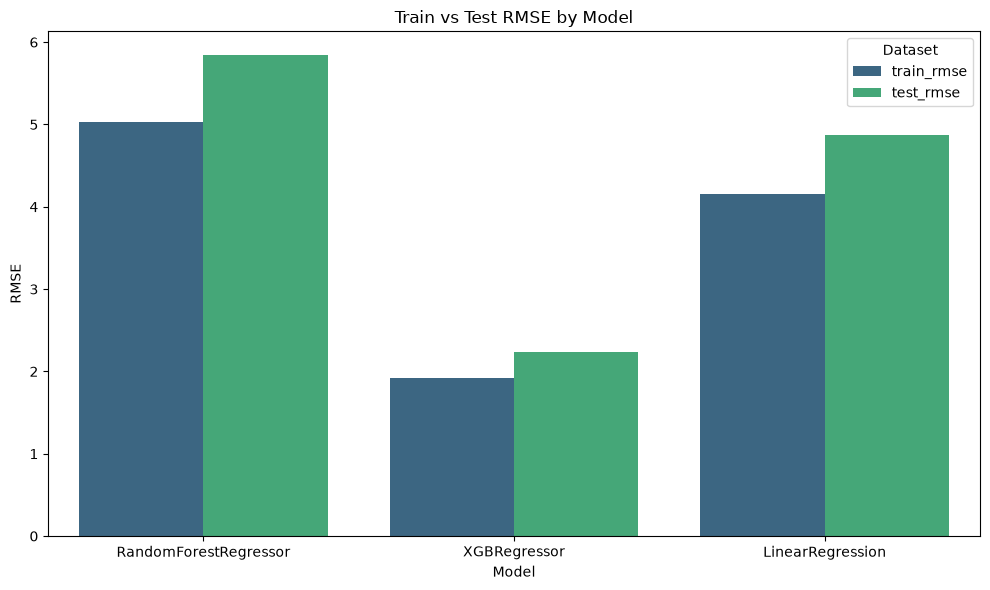

In [37]:
rmse_df = df[[
    "params.model_type",
    "metrics.train_rmse",
    "metrics.test_rmse"
]].copy()
rmse_df.columns = ["model", "train_rmse", "test_rmse"]
rmse_long = rmse_df.melt(
    id_vars="model",
    value_vars=["train_rmse", "test_rmse"],
    var_name="dataset",
    value_name="rmse"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=rmse_long,
    x="model",
    y="rmse",
    hue="dataset",
    palette="viridis"
)

plt.title("Train vs Test RMSE by Model")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.legend(title="Dataset")
plt.tight_layout()

save_path_RMSE = "../Graphs/Initial_RMSE_by_Model.png"

if not os.path.exists(save_path_RMSE):
    plt.savefig(save_path_RMSE, dpi=300, bbox_inches="tight")
    print("Saved plot.")
else:
    print("Plot already exists — skipping save.")

plt.show()



Saved plot.


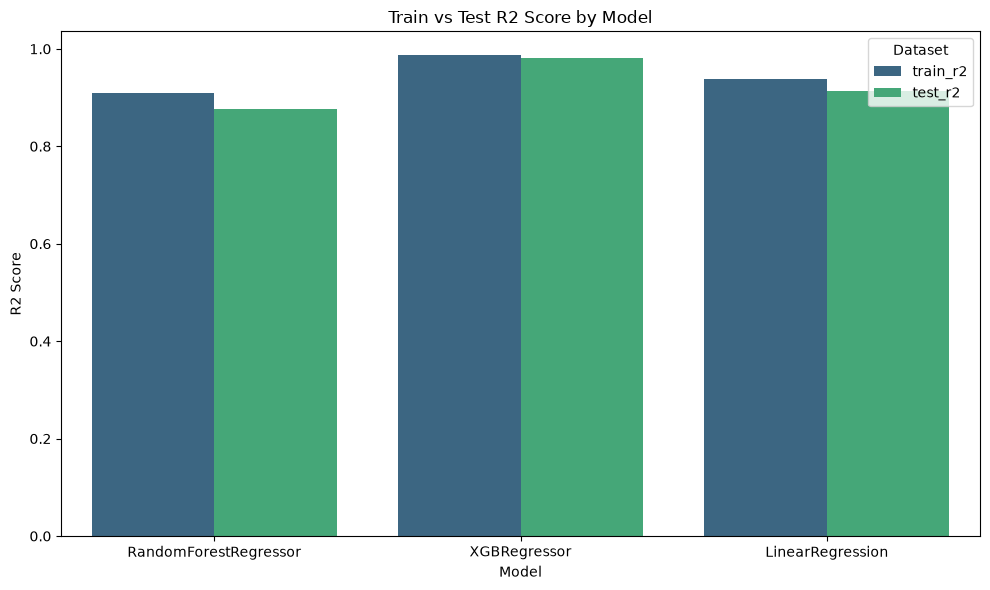

In [38]:
r2_df = df[[
    "params.model_type",
    "metrics.train_r2",
    "metrics.test_r2"
]].copy()
r2_df.columns = ["model", "train_r2", "test_r2"]
r2_long = r2_df.melt(
    id_vars="model",
    value_vars=["train_r2", "test_r2"],
    var_name="dataset",
    value_name="r2"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=r2_long,
    x="model",
    y="r2",
    hue="dataset",
    palette="viridis"
)

plt.title("Train vs Test R2 Score by Model")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.legend(title="Dataset")
plt.tight_layout()

save_path_R2 = "../Graphs/Initial_R2_by_Model.png"

if not os.path.exists(save_path_R2):
    plt.savefig(save_path_R2, dpi=300, bbox_inches="tight")
    print("Saved plot.")
else:
    print("Plot already exists — skipping save.")

plt.show()


The XGBoost model has the lowest RMSE error and the highest R2 score which suggests it is the best intital fit to the data.

## XGBoost Hyperparameter Tuning

In [22]:
xgb_search_space = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

N_ITER = 20
CV = 3


In [24]:
trainer = XGBTrainer()

with mlflow.start_run(run_name="XGBoost_Tuned"):
    best_params = trainer.tune(
        X_train,
        y_train,
        param_distributions=xgb_search_space,
        n_iter=N_ITER,
        cv=CV,
        scoring='neg_root_mean_squared_error'
    )

    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(best_params)
    trainer.print_results()


KeyboardInterrupt: 

## Random Forest Hyperparameter Tuning

In [ ]:
rf_search_space = {
    "n_estimators": [100, 200, 400],
    "max_depth": [10, 20, 40],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
trainer = RandomForestTrainer()

with mlflow.start_run(run_name="RandomForest_Tuned"):
    best_params = trainer.tune(
        X_train,
        y_train,
        param_distributions=rf_search_space,
        n_iter=20,
        cv=3
    )

    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(best_params)
    trainer.print_results()